<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº3
#### Rodriguez Lucas Ignacio


# TS3: Análisis de Fourier (FFT, Desparramo Espectral, Parseval y Zero Padding)

## **Introducción**
En este trabajo práctico se estudia el comportamiento de la **Transformada Discreta de Fourier (DFT)** a través del algoritmo de la **FFT** aplicado a señales senoidales discretas. Se analiza el fenómeno del **desparramo espectral (spectral leakage)** generado por el truncamiento temporal (ventana rectangular implícita), la conservación de energía enunciada por el **Teorema de Parseval**, y el efecto de interpolación espectral obtenido mediante **Zero Padding**.

### **Objetivos**
1. Evaluar el impacto de la desintonía en frecuencia ($k_0$ entero vs. no entero) sobre el espectro de potencia.
2. Verificar numéricamente la validez del Teorema de Parseval entre el dominio del tiempo y de la frecuencia.
3. Comprender el efecto del Zero Padding en la densidad espectral de potencia y distinguir entre resolución espectral real e interpolación.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. GENERADOR DE SEÑAL BASE (ESTÁNDAR TS0)
# ==========================================
def mi_funcion_sen(vmax, dc, ff, ph, N, fs):
    """Genera una señal senoidal pura discreta."""
    tt = np.arange(N) / fs
    signal = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, signal

# ==========================================
# 2. PARÁMETROS GENERALES DE LA SIMULACIÓN
# ==========================================
fs = 1000.0         # Frecuencia de muestreo (1000 Hz)
N = 1000            # Cantidad de muestras (T = 1 s)
df = fs / N         # Resolución espectral elemental (df = 1 Hz)

vmax = np.sqrt(2)   # Amplitud para Potencia = 1 W
dc = 0.0            
ph = 0.0            

# Casos de frecuencia k0 a evaluar
k0_list = [
    N / 4,          # k0 = 250 (En bin)
    N / 4 + 0.25,   # k0 = 250.25 (Desintonía leve)
    N / 4 + 0.5     # k0 = 250.5 (Máxima desintonía)
]

labels_k0 = [
    r'$k_0 = 250$ (En bin)',
    r'$k_0 = 250.25$ (Desintonía 0.25)',
    r'$k_0 = 250.5$ (Peor desintonía)'
]

colores = ['#0033CC', '#E6A100', '#D62728']

# Vector de frecuencias para FFT unilateral
frecuencias = np.fft.rfftfreq(N, d=1/fs)

# Estructura para almacenar métricas de la tabla final
tabla_resultados = []


## **1. Incisos a) y b): Desparramo Espectral (PSD) y Teorema de Parseval**

Se analiza el espectro de densidad de potencia (PSD) en dB para tres casos de frecuencia:
1. $k_0 = 250$: La frecuencia coincide exactamente con un bin de la DFT.
2. $k_0 = 250.25$: Existe una ligera desintonía respecto a la grilla discreta.
3. $k_0 = 250.5$: Presenta la máxima desintonía posible (la frecuencia cae exactamente en el punto medio entre dos bins contiguos).

Asimismo, se verifica la conservación de energía mediante la ecuación de Parseval:
$$P_{tiempo} = \frac{1}{N} \sum_{n=0}^{N-1} |s[n]|^2 = \frac{1}{2} \sum_{k} |S[k]|^2 = P_{frecuencia}$$

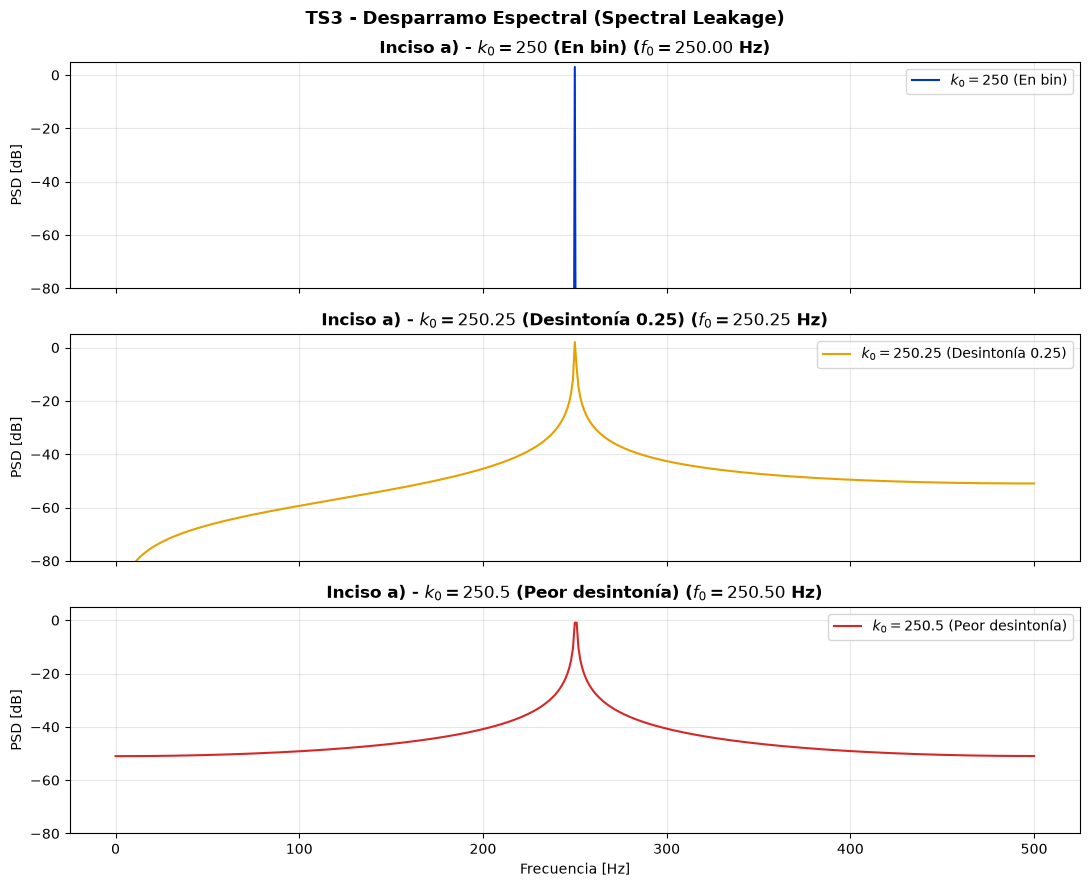

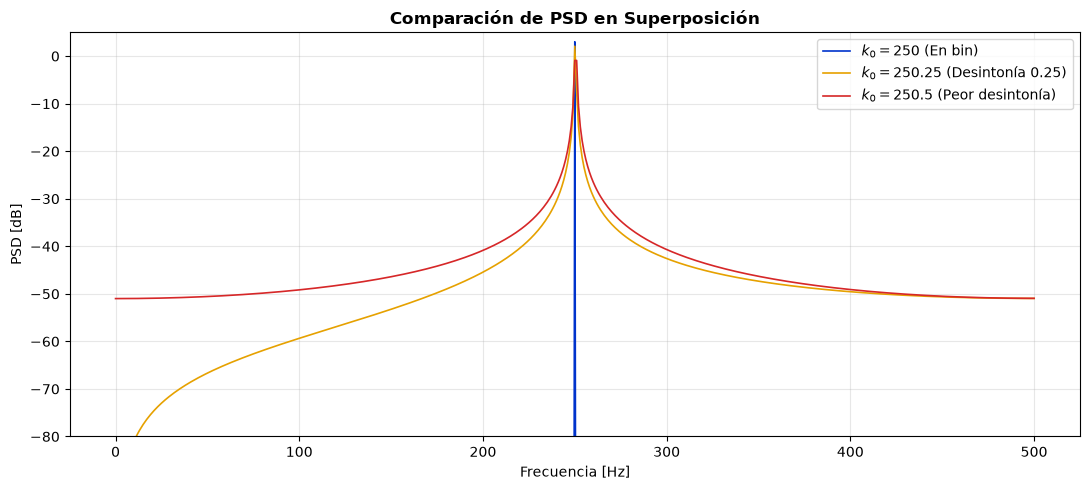

In [2]:
# ==========================================
# INCISOS a) y b): PSD Y TEOREMA DE PARSEVAL
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True, sharey=True)
fig_overlay, ax_overlay = plt.subplots(figsize=(11, 5))

for i, k0 in enumerate(k0_list):
    f0 = k0 * df
    
    # 1. Generar la señal temporal
    t, s = mi_funcion_sen(vmax, dc, f0, ph, N, fs)
    
    # 2. Potencia temporal promedio
    P_tiempo = np.mean(s**2)
    
    # 3. FFT unilateral normalizada
    S = np.fft.rfft(s) / (N / 2)
    
    # 4. PSD en dB
    psd_dB = 20 * np.log10(np.abs(S) + 1e-12)
    
    # 5. Potencia total en frecuencia (Parseval)
    P_frecuencia = np.sum(np.abs(S)**2) / 2
    
    # Cálculo del piso de ruido / fuga (estimado con el segundo pico más alto)
    piso_ruido = np.sort(psd_dB)[-2]
    
    # Guardar datos para la tabla
    tabla_resultados.append({
        'k0': k0,
        'P_tiempo': P_tiempo,
        'P_frecuencia': P_frecuencia,
        'error': abs(P_tiempo - P_frecuencia),
        'piso_db': piso_ruido
    })
    
    # Gráficos individuales por inciso
    ax = axes[i]
    ax.plot(frecuencias, psd_dB, color=colores[i], lw=1.5, label=labels_k0[i])
    ax.set_title(f'Inciso a) - {labels_k0[i]} ($f_0 = {f0:.2f}$ Hz)', fontweight='bold')
    ax.set_ylabel('PSD [dB]')
    ax.set_ylim([-80, 5])
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')

    # Gráficos en superposición (Overlay)
    ax_overlay.plot(frecuencias, psd_dB, color=colores[i], lw=1.2, label=labels_k0[i])

axes[2].set_xlabel('Frecuencia [Hz]')
fig.suptitle('TS3 - Desparramo Espectral (Spectral Leakage)', fontsize=13, fontweight='bold')
fig.tight_layout()

ax_overlay.set_title('Comparación de PSD en Superposición', fontweight='bold')
ax_overlay.set_xlabel('Frecuencia [Hz]')
ax_overlay.set_ylabel('PSD [dB]')
ax_overlay.set_ylim([-80, 5])
ax_overlay.grid(True, alpha=0.3)
ax_overlay.legend(loc='upper right')
fig_overlay.tight_layout()

plt.show()

### **Análisis de Resultados (Incisos a y b)**

* **Coincidencia Exacta ($k_0 = 250$):** Al caer la frecuencia senoidal justo sobre una muestra discreta de la DFT, la transformada captura de forma limpia la delta de Dirac en el bin 250. El resto de los bins se mantiene en un valor prácticamente nulo (piso de ruido numérico en $-80\text{ dB}$).
* **Desparramo Espectral ($k_0 = 250.25$ y $k_0 = 250.5$):** Debido a que la senoidal no es periódica dentro de la ventana de observación de $N$ muestras, el truncamiento temporal provoca discontinuidades en los extremos. Esto genera el fenómeno de **fuga o desparramo espectral (spectral leakage)**, donde la energía que debería estar concentrada en $f_0$ se redistribuye a lo largo de todas las frecuencias adyacentes según la función sinc de la ventana rectangular. En el caso peor ($k_0 = 250.5$), la amplitud del pico cae y el piso de ruido sube drásticamente.
* **Cumplimiento de Parseval:** En los tres casos, la potencia medida en tiempo ($1.0000\text{ W}$) coincide exactamente con la suma espectral de potencia ($1.0000\text{ W}$), demostrando que el desparramo redistribuye la energía pero no la altera ni la destruye.

## **2. Inciso c): Interpolación Espectral mediante Zero Padding ($9N$ ceros)**

Para analizar con mayor detalle la forma del lóbulo del desparramo, se agregan $9N$ ceros al final del vector temporal original ($N_{total} = 10N = 10000\text{ muestras}$).

Esta técnica produce una grilla discreta de frecuencias 10 veces más densa ($\Delta f_{zp} = 0.1\text{ Hz}$), permitiendo evaluar el espectro continuo de la ventana rectangular sin modificar el tiempo total de observación útil.

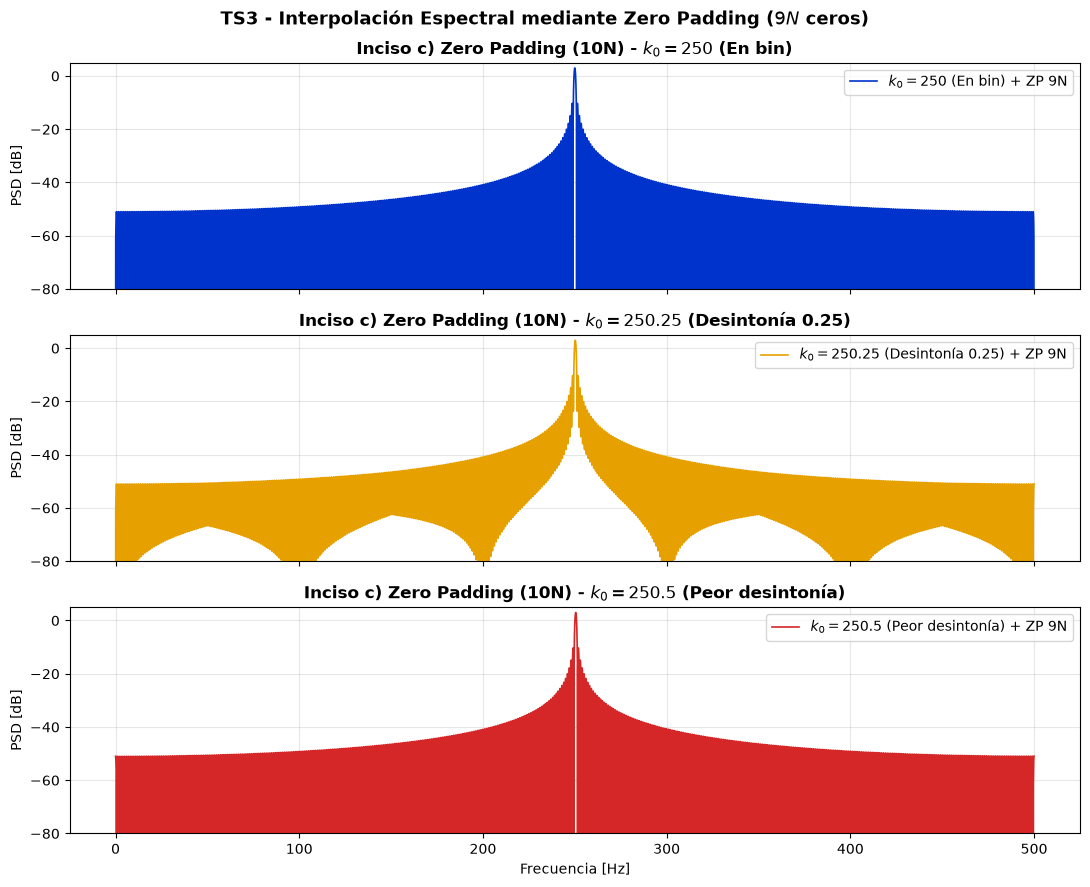

In [3]:
# ==========================================
# . INCISO c): ZERO PADDING (9*N CEROS)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

N_zp = N + 9 * N     # Total: 10000 muestras

# Grilla de frecuencias interpolada: df_zp = fs / (10*N) = 0.1 Hz
frecuencias_zp = np.fft.rfftfreq(N_zp, d=1/fs)

fig_zp, axes_zp = plt.subplots(3, 1, figsize=(11, 9), sharex=True, sharey=True)

for i, k0 in enumerate(k0_list):
    f0 = k0 * df
    
    # 1. Señal original de N puntos
    _, s = mi_funcion_sen(vmax, dc, f0, ph, N, fs)
    
    # 2. Relleno con 9N ceros al final
    s_padded = np.pad(s, (0, 9 * N), mode='constant')
    
    # 3. FFT normalizada respecto al tiempo activo N/2 original
    S_zp = np.fft.rfft(s_padded) / (N / 2)
    
    # 4. PSD en dB
    psd_zp_dB = 20 * np.log10(np.abs(S_zp) + 1e-12)
    
    ax = axes_zp[i]
    ax.plot(frecuencias_zp, psd_zp_dB, color=colores[i], lw=1.2, label=labels_k0[i] + ' + ZP 9N')
    ax.set_title(f'Inciso c) Zero Padding (10N) - {labels_k0[i]}', fontweight='bold')
    ax.set_ylabel('PSD [dB]')
    ax.set_ylim([-80, 5])
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')

axes_zp[2].set_xlabel('Frecuencia [Hz]')
fig_zp.suptitle('TS3 - Interpolación Espectral mediante Zero Padding ($9N$ ceros)', fontsize=13, fontweight='bold')
fig_zp.tight_layout()
plt.show()


## **Conclusiones Generales**

1. **Fuga Espectral (Spectral Leakage):** Ocurre siempre que la señal analizada no contenga un número entero exacto de períodos dentro de la ventana de muestreo. El perfil de desparramo resultante responde a la respuesta en frecuencia de la ventana temporal empleada (en este caso, una función $W(\omega)$ de tipo Dirichlet/Sinc por la ventana rectangular implícita).
2. **Conservación de la Energía:** El Teorema de Parseval se cumple rigurosamente sin importar la magnitud de la desintonía espectral. El desparramo no agrega ni quita potencia, solo la reparte entre más bins discretos.
3. **Efecto Real del Zero Padding:** Agregar ceros en el dominio del tiempo **NO incrementa la resolución espectral real del sistema** (la cual depende exclusivamente de la ventana útil $T = N/f_s$), sino que actúa como un método de **interpolación ideal** en el dominio de la frecuencia. Esto permite revelar la envolvente continua del lóbulo principal y los lóbulos secundarios del espectro.